c:\Users\babie\OneDrive\바탕 화면\임시 ms 폴더
c:\Users\babie\OneDrive\바탕 화면
0 train acc, test acc | 0.09751666666666667 , 0.0974
600 train acc, test acc | 0.8693666666666666 , 0.8744
1200 train acc, test acc | 0.9067833333333334 , 0.9088
1800 train acc, test acc | 0.9169833333333334 , 0.9172
2400 train acc, test acc | 0.9247 , 0.9247
3000 train acc, test acc | 0.9313333333333333 , 0.9318
3600 train acc, test acc | 0.9366833333333333 , 0.9365
4200 train acc, test acc | 0.9412666666666667 , 0.9406
4800 train acc, test acc | 0.9451333333333334 , 0.9422
5400 train acc, test acc | 0.9481333333333334 , 0.9449
6000 train acc, test acc | 0.9491666666666667 , 0.9461
6600 train acc, test acc | 0.95365 , 0.95
7200 train acc, test acc | 0.9551666666666667 , 0.9517
7800 train acc, test acc | 0.9571833333333334 , 0.9526
8400 train acc, test acc | 0.9587833333333333 , 0.9539
9000 train acc, test acc | 0.9613666666666667 , 0.9573
9600 train acc, test acc | 0.9628166666666667 , 0.9572


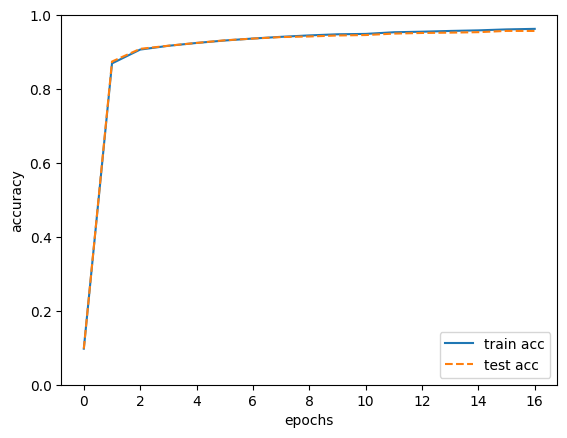

In [2]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch03.two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼파라미터
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.2

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 학습 루프
for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    # grad = network.numerical_gradient(x_batch, t_batch)  # (선택)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산 및 기록
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(i, "train acc, test acc |", train_acc, ",", test_acc)

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


c:\Users\babie\OneDrive\바탕 화면
c:\Users\babie\OneDrive
0 train acc, test acc | 0.09736666666666667 , 0.0982
600 train acc, test acc | 0.8741833333333333 , 0.8758
1200 train acc, test acc | 0.90645 , 0.9092
1800 train acc, test acc | 0.9188833333333334 , 0.9215
2400 train acc, test acc | 0.9263166666666667 , 0.9288
3000 train acc, test acc | 0.9321833333333334 , 0.9332
3600 train acc, test acc | 0.9383166666666667 , 0.937
4200 train acc, test acc | 0.9430666666666667 , 0.9431
4800 train acc, test acc | 0.94615 , 0.9459
5400 train acc, test acc | 0.9489333333333333 , 0.9484
6000 train acc, test acc | 0.9516333333333333 , 0.9515
6600 train acc, test acc | 0.9547333333333333 , 0.9534
7200 train acc, test acc | 0.9572 , 0.9541
7800 train acc, test acc | 0.9591333333333333 , 0.9564
8400 train acc, test acc | 0.95975 , 0.9551
9000 train acc, test acc | 0.96195 , 0.9563
9600 train acc, test acc | 0.96335 , 0.9588
10200 train acc, test acc | 0.9652833333333334 , 0.9598
10800 train acc, test acc 

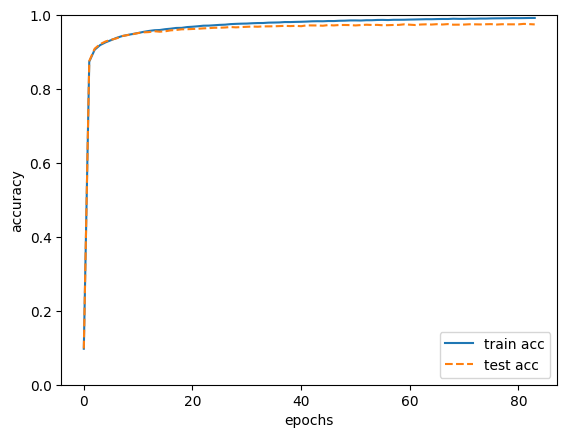

In [3]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch03.two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼파라미터
iters_num = 50000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.2

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 학습 루프
for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    # grad = network.numerical_gradient(x_batch, t_batch)  # (선택)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산 및 기록
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(i, "train acc, test acc |", train_acc, ",", test_acc)

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


In [5]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch03.two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

# 하이퍼파라미터
iters_num = 100000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.2

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 학습 루프
for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    # grad = network.numerical_gradient(x_batch, t_batch)  # (선택)

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산 및 기록
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(i, "train acc, test acc |", train_acc, ",", test_acc)

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


c:\Users\babie
c:\Users
0 train acc, test acc | 0.09838333333333334 , 0.1025
600 train acc, test acc | 0.8746833333333334 , 0.8777
1200 train acc, test acc | 0.9066166666666666 , 0.9084
1800 train acc, test acc | 0.9181 , 0.9209
2400 train acc, test acc | 0.9254166666666667 , 0.9271
3000 train acc, test acc | 0.9320166666666667 , 0.9326
3600 train acc, test acc | 0.9357833333333333 , 0.9372
4200 train acc, test acc | 0.9407666666666666 , 0.9395
4800 train acc, test acc | 0.94535 , 0.943
5400 train acc, test acc | 0.9479166666666666 , 0.9444
6000 train acc, test acc | 0.951 , 0.9468
6600 train acc, test acc | 0.9539166666666666 , 0.9513
7200 train acc, test acc | 0.9552833333333334 , 0.9531
7800 train acc, test acc | 0.9568833333333333 , 0.9531
8400 train acc, test acc | 0.9591166666666666 , 0.9559
9000 train acc, test acc | 0.9610833333333333 , 0.9565
9600 train acc, test acc | 0.9623833333333334 , 0.9586
10200 train acc, test acc | 0.96435 , 0.9591
10800 train acc, test acc | 0.965216

KeyboardInterrupt: 

## 가장 높은 정확도
- network = TwoLayerNet(input_size=784, hidden_size=70, output_size=10)

- 하이퍼파라미터
    - iters_num = 50000 
    - train_size = x_train.shape[0]
    - batch_size = 100
    - learning_rate = 0.4

c:\
c:\
0 train acc, test acc | 0.10441666666666667 , 0.1028
600 train acc, test acc | 0.9059 , 0.9101
1200 train acc, test acc | 0.9247 , 0.9268
1800 train acc, test acc | 0.9374833333333333 , 0.9384
2400 train acc, test acc | 0.9446 , 0.9447
3000 train acc, test acc | 0.9505 , 0.9489
3600 train acc, test acc | 0.9561666666666667 , 0.9532
4200 train acc, test acc | 0.96055 , 0.9581
4800 train acc, test acc | 0.9643333333333334 , 0.9614
5400 train acc, test acc | 0.9671166666666666 , 0.9632
6000 train acc, test acc | 0.9705833333333334 , 0.9653
6600 train acc, test acc | 0.97225 , 0.9651
7200 train acc, test acc | 0.97425 , 0.9679
7800 train acc, test acc | 0.9758 , 0.967
8400 train acc, test acc | 0.9767833333333333 , 0.9702
9000 train acc, test acc | 0.9784 , 0.9698
9600 train acc, test acc | 0.9792333333333333 , 0.9717
10200 train acc, test acc | 0.9806833333333334 , 0.9726
10800 train acc, test acc | 0.9814166666666667 , 0.9735
11400 train acc, test acc | 0.9819666666666667 , 0.972

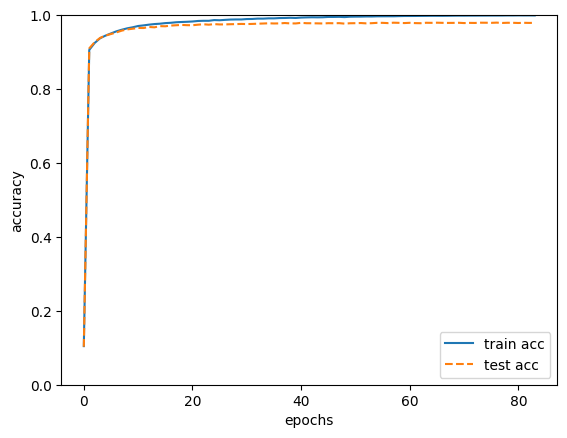

In [10]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch03.two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=70, output_size=10)

# 하이퍼파라미터
iters_num = 50000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.4

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 학습 루프
for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    #grad = network.numerical_gradient(x_batch, t_batch)  # (선택) # 수치미분을 사용하면 훨씬 오래걸림

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산 및 기록
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(i, "train acc, test acc |", train_acc, ",", test_acc)

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


- 수치 미분은 너무 오래걸리기 때문에 역전파 미분 방법으로 돌리고 있음
- hidden layer를 늘리면 학습 시간이 지수배로 늘어남

c:\
c:\
0 train acc, test acc | 0.10441666666666667 , 0.1028
600 train acc, test acc | 0.9065333333333333 , 0.9081
1200 train acc, test acc | 0.9236833333333333 , 0.9257
1800 train acc, test acc | 0.9366333333333333 , 0.9363
2400 train acc, test acc | 0.9451833333333334 , 0.9426
3000 train acc, test acc | 0.9493 , 0.9476
3600 train acc, test acc | 0.9557333333333333 , 0.9527
4200 train acc, test acc | 0.9607166666666667 , 0.9565
4800 train acc, test acc | 0.9630666666666666 , 0.9595
5400 train acc, test acc | 0.9656166666666667 , 0.9612
6000 train acc, test acc | 0.9690166666666666 , 0.9632
6600 train acc, test acc | 0.9707 , 0.963
7200 train acc, test acc | 0.97355 , 0.9657
7800 train acc, test acc | 0.97575 , 0.9678
8400 train acc, test acc | 0.9763833333333334 , 0.9671
9000 train acc, test acc | 0.9781666666666666 , 0.9683
9600 train acc, test acc | 0.9799 , 0.9691
10200 train acc, test acc | 0.9809833333333333 , 0.97
10800 train acc, test acc | 0.9819833333333333 , 0.9712
11400 tra

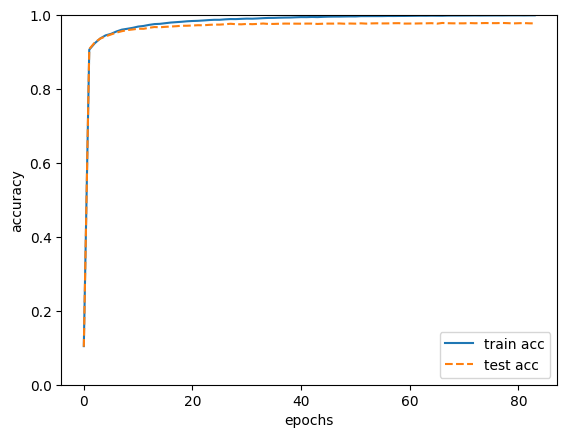

In [12]:
import os, sys
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
os.chdir(current_dir)

import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from ch03.two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=80, output_size=10)

# 하이퍼파라미터
iters_num = 50000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.4

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

# 학습 루프
for i in range(iters_num):
    # 미니배치 획득
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # 기울기 계산
    grad = network.gradient(x_batch, t_batch)
    #grad = network.numerical_gradient(x_batch, t_batch)  # (선택) # 수치미분을 사용하면 훨씬 오래걸림

    # 매개변수 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]

    # 학습 경과 기록
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    # 1에폭당 정확도 계산 및 기록
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(i, "train acc, test acc |", train_acc, ",", test_acc)

# 그래프 그리기
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()
